Purpose: To explore the Bhutan basin boundary from the Bhutan NSDI System website.

Install libraries </bt>
- here on the notebook or 
- from terminal within a python virtual environment<br/>

For Notebook option <br/>
 ```
 !pip install --upgrade pip
 !pip install -r requirements.txt
 ``` 
<br/>

For terminal option <br/>
open up a new terminal for instance in a VSCode environment
```
> python -m venv bb_venv <br/>
> bb_venv\Scripts\activate.bat <br/>
(bb_venv)> python -m pip install --upgrade pip  <br/>
(bb_venv)> pip install -r requirements.txt <br/>
```
<br/>


**NOTE:First time run, you need to choose the python environment and it might install ipykernel as well**

**Import Libraries**

In [1]:
import os

# from arcgis.gis import GIS
import pandas as pd
# from arcgis.features import GeoAccessor, FeatureLayer
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt 


arcgis - needs the following libraries installed
- arcgis
- shapely or fiona (I just installed both)
- geopandas
- arcpy
- pyproj
- rtree

NOTE: But for this notebook we aren't using as some features need paid version of ARCGIS.



In [2]:
cwd = os.getcwd()
cwd


'c:\\PS\\Projects\\Omdena\\ClimateSense\\bhutan_basin'

**Load the previously downloaded Bhutan - basin boundary data as a .shp file**

In [3]:
boun_shp_file = "./data/Basin boundary.shp"

In [ ]:
# # Option 1: Load shp file as shown here by setting the fiona
# #           SHAPE config 
# # Set geoPandas - fiona engine SHAPE config options
# gdf_orig = None
# with fiona.Env(SHAPE_RESTORE_SHX='YES'):
#     # load the shp file
#     gdf_orig = gpd.read_file(boun_shp_file)
#     print(f"Total rows of basin boundary available: {gdf_orig.shape[0]}")
# gdf_orig.head(2)

Total rows of basin boundary available: 10


,basin,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are,geometry
0,Aiechhu,E:\2024-2025\Basin_boundaries\Aiechhu.shp,196390.588555,1963.905886,337019.366034,2.481073e+09,"POLYGON ((10058028.821 3151062.425, 10058067.6..."
1,Merak_Sakteng,E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,13881.067718,138.810677,76767.739616,1.763939e+08,"POLYGON ((10245694.293 3155611.158, 10245655.4..."


In [6]:
# Option 2: directly load the shape file with fiona
gdf_orig = None
# NOTE: features are the rows from the shp file
# Refer: https://gis.stackexchange.com/questions/448450/getting-the-number-of-features-in-shapefile-without-opening-it-using-python
#
# If we have arcgis account then we can use, similar to below link...
# Refer: https://gis.stackexchange.com/questions/381120/convert-arcgis-spatially-enabled-dataframe-to-geopandas-geodataframe

# load shp file
with fiona.open(boun_shp_file) as features:
    print(f"Total features in basin boundary .shp file: {len(features)}")

    gdf_orig = gpd.GeoDataFrame.from_features(features)
    print(f"Loaded geoDataFrame shape: {gdf_orig.shape}")
gdf_orig.head(2)


Total features in basin boundary .shp file: 10
Loaded geoDataFrame shape: (10, 7)


,geometry,basin,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are
0,"POLYGON ((10058028.821 3151062.425, 10058067.6...",Aiechhu,E:\2024-2025\Basin_boundaries\Aiechhu.shp,196390.588555,1963.905886,337019.366034,2.481073e+09
1,"POLYGON ((10245694.293 3155611.158, 10245655.4...",Merak_Sakteng,E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,13881.067718,138.810677,76767.739616,1.763939e+08


In [7]:
#  Derive latitude and longitude
gdf = gdf_orig.copy(deep=True)
# option 1:
# gdf['longitude'] = gdf['geometry'].x
# gdf['latitude'] = gdf['geometry'].y

# option 2:
gdf.insert(1, "longitude", gdf['geometry'].geometry.centroid.x)
gdf.insert(2, "latitude", gdf['geometry'].geometry.centroid.y)
gdf.head(2)

,geometry,longitude,latitude,basin,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are
0,"POLYGON ((10058028.821 3151062.425, 10058067.6...",1.007049e+07,3.116731e+06,Aiechhu,E:\2024-2025\Basin_boundaries\Aiechhu.shp,196390.588555,1963.905886,337019.366034,2.481073e+09
1,"POLYGON ((10245694.293 3155611.158, 10245655.4...",1.024517e+07,3.164758e+06,Merak_Sakteng,E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,13881.067718,138.810677,76767.739616,1.763939e+08


**Visualize the geoDataFrame**

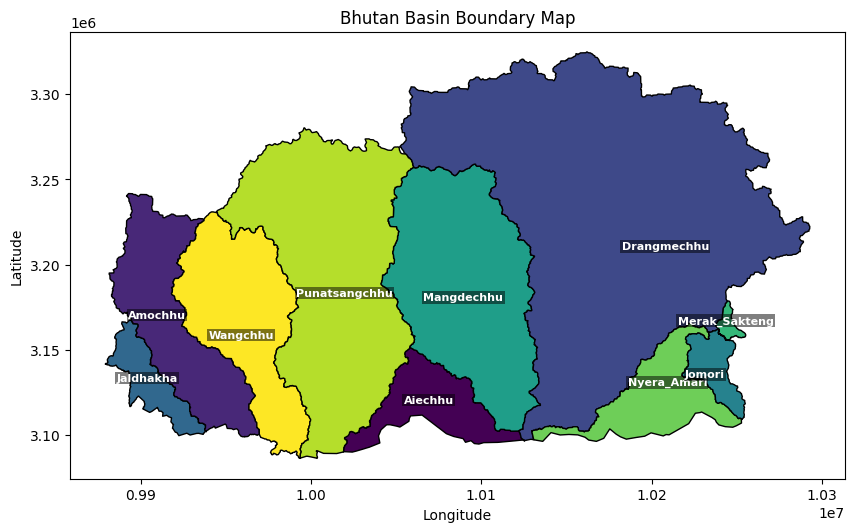

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# gdf.plot(ax=ax, column='basin', color='red', edgecolor='black') # tab20
gdf.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black') #, legend=True)
# Add basin name labels
for idx, row in gdf.iterrows():
    centroid = row.geometry.representative_point()
    ax.text(centroid.x, centroid.y, row['basin'],
            horizontalalignment='center', verticalalignment='center',
            fontsize=8, color='white', weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))
    
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.title("Bhutan Basin Boundary Map")
plt.show()

In [ ]:
try:
    sdf = pd.DataFrame.spatial.from_featureclass(boun_shp_file)
    print("Shapefile loaded successfully.")
except Exception as e:
    print(f"Error loading shapefile: {e}")
    sdf = None # Handle the case where loading fails

In [ ]:
gpd.GeoDataFrame.read_file(gjson_string, driver='GeoJSON')

In [ ]:
gdf.from_layer()

In [ ]:
# # Create a Spatially Enabled DataFrame
# sdf = pd.DataFrame.spatial.from_layer(feature_layer)